# Assignment 2

This assignment follows up from the initial exploratory analysis and discussion reported in assignment 1, which reviewed a maternal health dataset, seeking to replicate risk classification to ensure a transparent and usable model for risk assessment. The target variable is Risk Level (High vs Low). Models are evaluated primarily using the F2 score, which places greater emphasis on sensitivity (recall) because failing to identify a high-risk pregnancy is considered clinically more serious than generating additional false positives.

In [56]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, 
    fbeta_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)
from sklearn import svm, datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
sns.set_theme(style="whitegrid")

In [20]:
# import datasets
train_df = pd.read_csv("./cleaned_train.csv")
val_df = pd.read_csv("./cleaned_validation.csv")
test_df = pd.read_csv("./cleaned_test.csv")


Although for assignment 1, I separated the dataset into separate datasets for training and validation as well as testing, I recondiered and decided to adopt cross validation in order to give a more stable estimate of model performance, due to the relatively small sample size.

The original dataset had already been split into training, validation, and test sets. Missing-value handling and any preprocessing decisions were applied within the training/validation workflow, while the test set remained untouched until final model evaluation.

In [21]:
train_df = pd.read_csv("./cleaned_train.csv")
val_df = pd.read_csv("./cleaned_validation.csv")

target_col = "Risk Level"
risk_map = {"High": 1, "Low": 0}

for df in [train_df, val_df]:
    df[target_col] = df[target_col].map(risk_map)

feature_cols = [c for c in train_df.columns if c != target_col]

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_trainval = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_trainval = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

print(y_trainval.value_counts(normalize=True))
print(X_trainval.shape)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Risk Level
0    0.603226
1    0.396774
Name: proportion, dtype: float64
(930, 11)


As above, the merged training + validation dataset has a similar stratification of risk level to the training set.

## Scoring/Evaluation

F2 is a very important metric for evaluating the models, and will be used accross the models, so is defined here before the models.

In [22]:
# beta = 2 -> F2 (not F1 score)
# pos_label=1 means High Risk = 1 is the positive value
f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)

# Naive Prediction

Just for the sake of comparision, as mentioned in Assignment 1, simply predicting everyone as low risk should result in an accuracy level of 60%. Here the confusion matrix is constructed to test that assumption

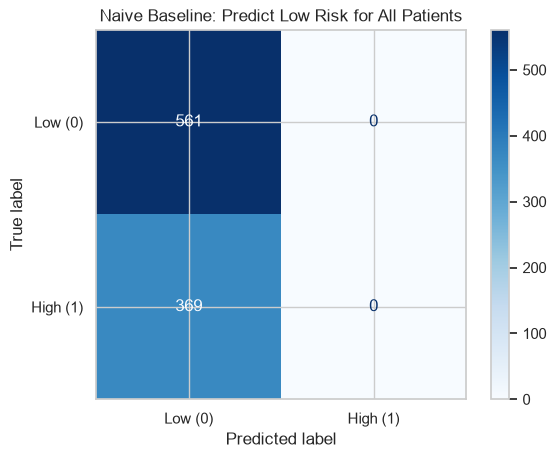

Naive baseline F2 score: 0.0000


In [23]:
y_naive_pred = np.zeros_like(y_trainval)

cm = confusion_matrix(y_trainval, y_naive_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low (0)', 'High (1)'])
disp.plot(cmap='Blues')
plt.title('Naive Baseline: Predict Low Risk for All Patients')
plt.show()

naive_f2 = fbeta_score(y_trainval, y_naive_pred, beta=2, pos_label=1)
print(f"Naive baseline F2 score: {naive_f2:.4f}")

So any F2 score above 0 will be an improvement, and can be assessed for significance.

## Baseline Model: Logistic Regression

This is a logistic regression model. In contrast to the tree based models, here scaling is vitally important with different features having very different scales. The pipeline is as follows: raw data -> scaling -> logistic regression -> predictions.

Note in the parameter grid below, the clf__penalty choses to use lasso first and then ridge as there is some moderate multicolinearity (e.g. Mental Health and Previous Complications and/or Preexisting Diabetes). If Mental Health's contribution really is mostly redundant once the other two are accounted for, l1 regularisation may zero out its coefficient entirely during fitting, keeping only features that add genuinely independent predictive value.

In [24]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver='liblinear', max_iter=1000, random_state=42))
])

parameter_grid = {
    'clf__C': [0.01, 0.1, 1, 10, 100], # controls regularisation strength, smaller means simpler model
    'clf__penalty': ['l1', 'l2'], # l1 = lasso, l2 = ridge
    'clf__class_weight': ['balanced', None]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=parameter_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_trainval, y_trainval)

/Users/aislinglangston/Documents/CFG_2026/CFG +Masters/Maternal_health_assignment/tf_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/aislinglangston/Documents/CFG_2026/CFG +Masters/Maternal_health_assignment/tf_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/aislinglangston/Documents/CFG_2026/CFG +Masters/Maternal_health_assignment/tf_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWar

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.01, 0.1, ...], 'clf__class_weight': ['balanced', None], 'clf__penalty': ['l1', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","make_scorer(f..., pos_label=1)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will o

In [25]:
best_model = grid_search.best_estimator_
coefs = best_model.named_steps['clf'].coef_[0]
feature_names = X_trainval.columns

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False)
print(coef_df)

                   feature  coefficient
7     Preexisting Diabetes     1.582736
8     Gestational Diabetes     1.231714
9            Mental Health     0.883697
3                       BS     0.732465
10              Heart Rate     0.709093
6   Previous Complications     0.691067
5                      BMI     0.553082
2                Diastolic     0.426831
0                      Age    -0.389448
4                Body Temp     0.320348
1              Systolic BP     0.316451


The top three features identified in this logistic regression model are Preexisting Diabetes, Gestational Diabetes, and Mental Health. The first two were expected from the exploratory analysis, but Mental Health was not so anticipated. Another item to note is the apparent negative effect of age, which again is not so clinically plausible. These two findings therefore suggest that there is multicollinearity between correlated binary predictors, which can inflate or destabilise individual coefficient estimates in logistic regression. This indicates that a stable, interpretable reading of coefficients may be limited in this model, and motivates comparison against the tree-based models.

In [26]:
print("Best parameters:", grid_search.best_params_)
print("Best CV score (F2):", grid_search.best_score_)

Best parameters: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2'}
Best CV score (F2): 0.9696185058306501


This model achieved a very high cross-validated F2 score of 0.9696. While this implicitly suggests a strong predictive power, it is consistent with the possibility that the target variable is strongly determined by a small subset of predictors.

In [27]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('mean_test_score', ascending=False)

results_df[['params', 'mean_test_score', 'std_test_score', 'mean_train_score']].head(10)

,params,mean_test_score,std_test_score,mean_train_score
5,"{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2'}",0.969619,0.011255,0.971772
8,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l1'}",0.969091,0.011021,0.975166
17,"{'clf__C': 100, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2'}",0.969088,0.012408,0.975150
16,"{'clf__C': 100, 'clf__class_weight': 'balanced', 'clf__penalty': 'l1'}",0.969088,0.012408,0.975150
12,"{'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__penalty': 'l1'}",0.969088,0.012408,0.974606
13,"{'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2'}",0.969088,0.012408,0.975562
9,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2'}",0.968566,0.011808,0.974888
4,"{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l1'}",0.967026,0.011265,0.968851
7,"{'clf__C': 0.1, 'clf__class_weight': None, 'clf__penalty': 'l2'}",0.962233,0.022821,0.964924
6,"{'clf__C': 0.1, 'clf__class_weight': None, 'clf__penalty': 'l1'}",0.959797,0.018585,0.964817


## Model 2: Single Tree Model

Note that the single tree model provides several benefits over logistic regression. It allows for a very clear and potentially visual interpretation/replication of the rule-generated risk model, which can transparently show every split it chooses.

It is also unnecessary to scale in a single tree model, as thresholds are based on the features own ranges.

In [28]:
pipeline_tree = Pipeline([
    ('clf', DecisionTreeClassifier(random_state=42))
])

parameter_grid_tree = {
    'clf__max_depth': [2, 3, 4, 5, None],
    'clf__min_samples_leaf': [1, 5, 10, 20],
    'clf__criterion': ['gini', 'entropy'],
    'clf__class_weight': ['balanced', None]
}

grid_search_tree = GridSearchCV(
    estimator=pipeline_tree,
    param_grid=parameter_grid_tree,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid_search_tree.fit(X_trainval, y_trainval)

print("Best parameters:", grid_search_tree.best_params_)
print("Best CV score (F2):", grid_search_tree.best_score_)

Best parameters: {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 1}
Best CV score (F2): 0.9615938034042728


This model which is considered the 'best' has the minimum leaf size of 1, which would imply fitting to individual outlier patient(s). In order to interrogate this further, it is useful to review the difference in performance between the training data and the validation data.

In [29]:
results_df = pd.DataFrame(grid_search_tree.cv_results_)
best_row = results_df.loc[results_df['mean_test_score'].idxmax()]
print("Mean train score:", best_row['mean_train_score'])
print("Mean test (val) score:", best_row['mean_test_score'])
print("Std test score:", best_row['std_test_score'])

Mean train score: 1.0
Mean test (val) score: 0.9615938034042728
Std test score: 0.015649269917599715


As can be seen above, there is a difference between the performance with the training and validation data, which indicates evidence of overfitting.

In [30]:
results_df_sorted = results_df.sort_values('mean_test_score', ascending=False)
print(results_df_sorted[['params', 'mean_test_score', 'std_test_score', 'mean_train_score']].head(10))

                                                                                                                params  \
16     {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 1}   
12        {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 1}   
56           {'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 1}   
36  {'clf__class_weight': 'balanced', 'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_leaf': 1}   
17     {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 5}   
13        {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 5}   
76        {'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_leaf': 1}   
18    {'clf__class_weigh

In [31]:
pd.set_option('display.max_colwidth', None)
print(results_df_sorted[['params', 'mean_test_score', 'mean_train_score']].head(10).to_string())

                                                                                                                params  mean_test_score  mean_train_score
16     {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 1}         0.961594          1.000000
12        {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 1}         0.955044          0.983891
56           {'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 1}         0.953958          1.000000
36  {'clf__class_weight': 'balanced', 'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_leaf': 1}         0.952751          1.000000
17     {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 5}         0.950264          0.981166
13        {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__

In [32]:
shallow_results = results_df[results_df['params'].apply(lambda p: p['clf__max_depth'] in [2, 3])]
shallow_results_sorted = shallow_results.sort_values('mean_test_score', ascending=False)
print(shallow_results_sorted[['params', 'mean_test_score', 'mean_train_score']].head(10).to_string())

                                                                                                           params  mean_test_score  mean_train_score
5    {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 5}         0.924322          0.937605
6   {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 10}         0.924322          0.937655
7   {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 20}         0.922676          0.937920
4    {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 1}         0.922152          0.938407
47        {'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 20}         0.897895          0.906628
45         {'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_le

It is interesting to note the overall pattern here. There is a substantial difference in performance between different depths. A depth of 2 shows a validation performance of only 0.873 at best, while the best performance with a depth of 3 is 0.924. There continues to be an improvement as depth increases, with depth = 5 gets to 0.948, but this difference between a depth of 3 and a depth of 5 is not substantial, and therefore a more parsimonious model is preferred. A shallow tree is preferred because it provides a simpler decision rule that is easier for clinicians to inspect and potentially implement. 

At a depth of 3, there is equivalent performance with minimum leaf size of 5 or 10, so for the final model the minimum leaf size of 10 was chosen to reduce the risk of overfitting.

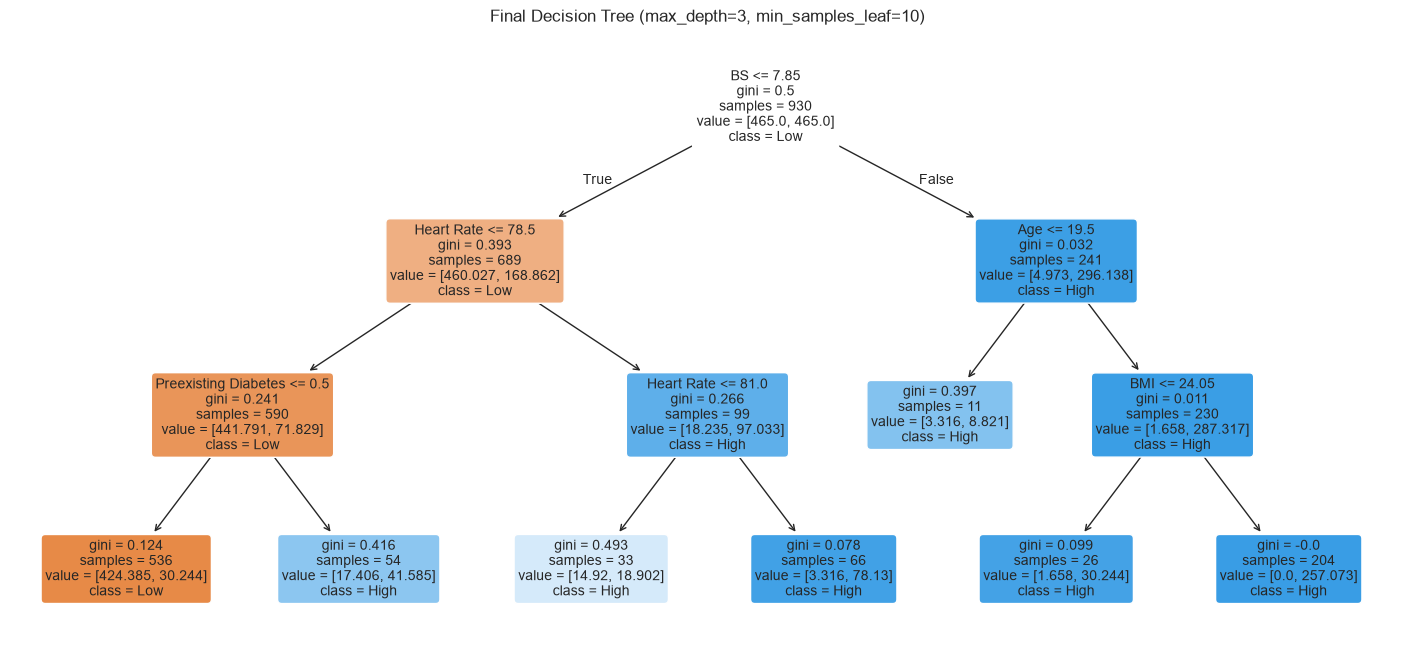

In [33]:
final_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=10,
    criterion='gini',
    class_weight='balanced',
    random_state=42
)

final_tree.fit(X_trainval, y_trainval)

plt.figure(figsize=(18, 8))
plot_tree(
    final_tree,
    feature_names=X_trainval.columns,
    class_names=['Low', 'High'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Final Decision Tree (max_depth=3, min_samples_leaf=10)')
plt.show()

In [34]:
print(export_text(final_tree, feature_names=list(X_trainval.columns)))

|--- BS <= 7.85
|   |--- Heart Rate <= 78.50
|   |   |--- Preexisting Diabetes <= 0.50
|   |   |   |--- class: 0
|   |   |--- Preexisting Diabetes >  0.50
|   |   |   |--- class: 1
|   |--- Heart Rate >  78.50
|   |   |--- Heart Rate <= 81.00
|   |   |   |--- class: 1
|   |   |--- Heart Rate >  81.00
|   |   |   |--- class: 1
|--- BS >  7.85
|   |--- Age <= 19.50
|   |   |--- class: 1
|   |--- Age >  19.50
|   |   |--- BMI <= 24.05
|   |   |   |--- class: 1
|   |   |--- BMI >  24.05
|   |   |   |--- class: 1



Contrary to expectations, the root split was on Blood Sugar (BS ≤ 7.85) rather than one of the Diabetes binary features. It is clinically plausible that this reflects blood sugar levels being closely linked to diabetes diagnosis and so this hypothesis is tested directly via point-biserial correlation.

In [35]:
r, p = stats.pointbiserialr(df['Gestational Diabetes'], df['BS'])
print(f"BS vs Gestational Diabetes: r = {r:.3f}, p = {p:.4f}")
r, p = stats.pointbiserialr(df['Preexisting Diabetes'], df['BS'])
print(f"BS vs Prexisting Diabetes: r = {r:.3f}, p = {p:.4f}")

BS vs Gestational Diabetes: r = 0.049, p = 0.4572
BS vs Prexisting Diabetes: r = 0.623, p = 0.0000


Blood Sugar and Preexisting Diabetes show a moderate-to-strong correlation (r=0.623, p<0.0001), suggesting shared but non-redundant information, consistent with preexisting diabetes typically presenting as consistently and chronically high blood sugar. 

This is corroborated by the decision tree's structure, where Preexisting Diabetes provides a further split within the low BS subgroup. It therefore retains discriminating power beyond what BS alone captures. 

It is possible and indeed probable that this BS value is a singular reading, but it is not specifically explained as such in the documentation for the dataset. Gestational Diabetes shows very low correlation with BS (r=0.049, p=0.457) despite gestational diabetes being diagnosed via blood sugar testing. This discrepancy could not be resolved from the available data and may reflect how BS was measured in this dataset. 

## Model 3: Random Forest Model

Random Forest extends a single decision tree by averaging predictions across many trees built from bootstrap samples and random subsets of features. This typically reduces variance and overfitting while retaining the ability to model nonlinear relationships and interactions between predictors.

The parameter grid for the Random Forest model was informed by the earlier single decision-tree model. As the single tree achieved its best validation performance with a shallow depth (3) and relatively large minimum leaf size (10), the Random Forest search was restricted to nearby values (depths 3–5 and leaf sizes 5–10). This reduced computational cost and retained the explainability benefits described above.

In [44]:
pipeline_rf = Pipeline([
    ('clf', RandomForestClassifier(random_state=42))
])

parameter_grid_rf = {
    'clf__n_estimators': [100, 300, 500, 1000],
    'clf__max_depth': [3, 5],
    'clf__min_samples_leaf': [5, 10],
    'clf__max_features': ['sqrt'],
    'clf__class_weight': ['balanced']
}

In [57]:
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=parameter_grid_rf,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search_rf.fit(X_trainval, y_trainval)
best_rf = grid_search_rf.best_estimator_

In [46]:
print("Best RF parameters:", grid_search_rf.best_params_)
print("Best RF CV F2:", grid_search_rf.best_score_)

Best RF parameters: {'clf__class_weight': 'balanced', 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 10, 'clf__n_estimators': 500}
Best RF CV F2: 0.9811929423054749


This Random Forest model achieved a very F2 score (0.9812), indicating excellent performance on the available dataset. Nevertheless, the result should be interpreted cautiously because the dataset is relatively small and as already mentioned, risk level may be strongly determined by a limited number of features.

In [47]:
results_rf = pd.DataFrame(grid_search_rf.cv_results_)
best_rf_row = results_rf.loc[results_rf['mean_test_score'].idxmax()]

print('Mean train F2:', best_rf_row['mean_train_score'])
print('Mean CV F2:', best_rf_row['mean_test_score'])
print('Std CV F2:', best_rf_row['std_test_score'])

Mean train F2: 0.985326046254779
Mean CV F2: 0.9811929423054749
Std CV F2: 0.0033315769208113527


The difference between test F2 values for training data versus validation data was only 0.004, indicating minimal evidence of overfitting. The standard deviation of the cross-validated F2 score was 0.003, demonstrating consistent performance across the validation folds.

In [51]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Mean_F2': [
        grid_search.best_score_,
        grid_search_tree.best_score_,
        grid_search_rf.best_score_
    ],
    'Std_F2': [
        grid_search.cv_results_['std_test_score'][grid_search.best_index_],
        grid_search_tree.cv_results_['std_test_score'][grid_search_tree.best_index_],
        grid_search_rf.cv_results_['std_test_score'][grid_search_rf.best_index_]
    ]
})

print(comparison_df)

                 Model   Mean_F2    Std_F2
0  Logistic Regression  0.969619  0.011255
1        Decision Tree  0.961594  0.015649
2        Random Forest  0.981193  0.003332


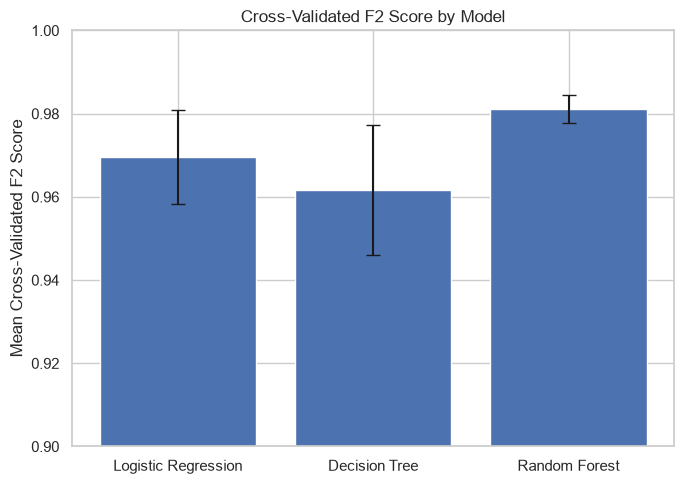

In [52]:
plt.figure(figsize=(7,5))

plt.bar(
    comparison_df['Model'],
    comparison_df['Mean_F2'],
    yerr=comparison_df['Std_F2'],
    capsize=5
)

plt.ylabel('Mean Cross-Validated F2 Score')
plt.ylim(0.9, 1.0)
plt.title('Cross-Validated F2 Score by Model')

plt.tight_layout()
plt.show()

As can be seen, random forest performs most strongly based on mean cross-validated F2 score, as well as having a smaller variance.

                 Model  Train_F2     CV_F2
0  Logistic Regression  0.971772  0.969619
1        Decision Tree  1.000000  0.961594
2        Random Forest  0.985326  0.981193


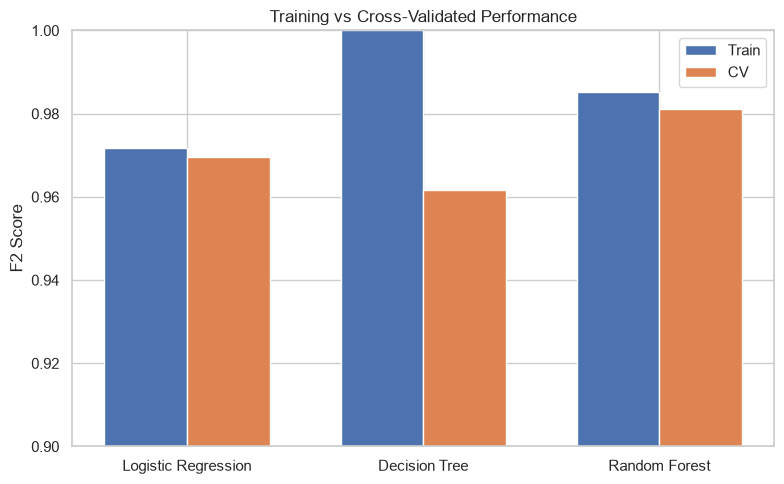

In [54]:
overfit_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Train_F2': [
        grid_search.cv_results_['mean_train_score'][grid_search.best_index_],
        grid_search_tree.cv_results_['mean_train_score'][grid_search_tree.best_index_],
        grid_search_rf.cv_results_['mean_train_score'][grid_search_rf.best_index_]
    ],
    'CV_F2': [
        grid_search.best_score_,
        grid_search_tree.best_score_,
        grid_search_rf.best_score_
    ]
})

print(overfit_df)

x = np.arange(len(overfit_df))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, overfit_df['Train_F2'], width, label='Train')
plt.bar(x + width/2, overfit_df['CV_F2'], width, label='CV')

plt.xticks(x, overfit_df['Model'])
plt.ylabel('F2 Score')
plt.ylim(0.9, 1.0)
plt.title('Training vs Cross-Validated Performance')
plt.legend()
plt.tight_layout()
plt.show()

# Final tests with testing dataset

In [ ]:
test_df = pd.read_csv("cleaned_test.csv")

X_test = test_df[feature_cols]
y_test = test_df["Risk Level"]

y_pred_rf = best_rf.predict(X_test)
y_pred_tree = final_tree.predict(X_test)
y_pred_lr = best_model.predict(X_test)


print("--- Logistic Regression Model ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr):.3f}")
print(f"F2 Score : {fbeta_score(y_test, y_pred_lr, beta=2):.3f}")